# Sampling

Generation runs the autoregressive loop: start with a class label token, then sample one token at a time using the GPT's predicted distribution. The full 8×8=64 token grid is then decoded by the VQ-VAE decoder into a 32×32 RGB image.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm 

%run 01_vqvae.ipynb
%run 03_transformer.ipynb

input:  torch.Size([4, 3, 32, 32])
x_hat: torch.Size([4, 3, 32, 32])
z_e: torch.Size([4, 32, 8, 8])
z_q: torch.Size([4, 32, 8, 8])
idx: torch.Size([4, 8, 8])
using mps
torch.Size([4, 64, 512])


In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'using {device}')

using mps


In [3]:
vqvae = VQVAE(K=512, d=32).to(device)
vqvae.load_state_dict(torch.load('../data/vqvae_cifar10.pt', map_location=device))
vqvae.eval()

gpt       = GPT(K=512, S=8, d_model=256, nhead=8, num_layers=8).to(device)
gpt.load_state_dict(torch.load('../data/gpt_cifar10_large_latest.pt', map_location=device))
gpt.eval()

vqvae, gpt

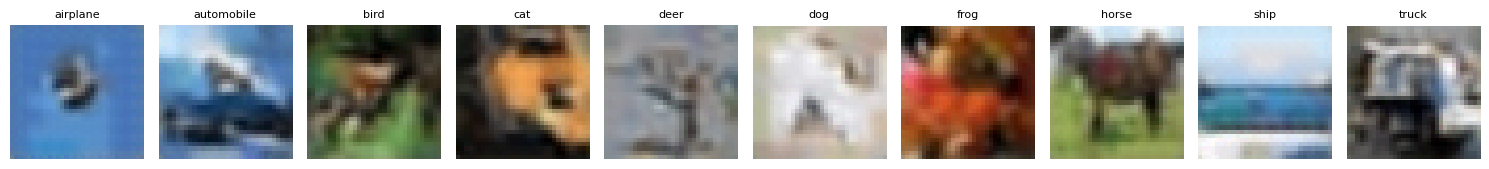

In [4]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

S = 8
d = 32

@torch.no_grad()
def generate(labels, temperature=1.0):
    B = labels.shape[0]
    x = torch.cat([labels.view(B, 1), torch.zeros(B, S*S, dtype=torch.long, device=device)], dim=1)
    for i in range(S*S):
        logits = gpt(x[:, :-1])[:, i, :] / temperature
        probs  = nn.functional.softmax(logits, dim=1)
        x[:, i+1] = torch.multinomial(probs, 1).squeeze()

    z_q = vqvae.vq.codebook[x[:, 1:]]
    z_q = z_q.transpose(1, 2).contiguous().view(B, d, S, S)
    return (vqvae.dec(z_q) + 1) / 2  # [-1, 1] -> [0, 1]

labels = torch.arange(10, dtype=torch.long, device=device)
images = generate(labels)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img.cpu().permute(1, 2, 0).clamp(0, 1))
    ax.set_title(CLASSES[label.item()], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

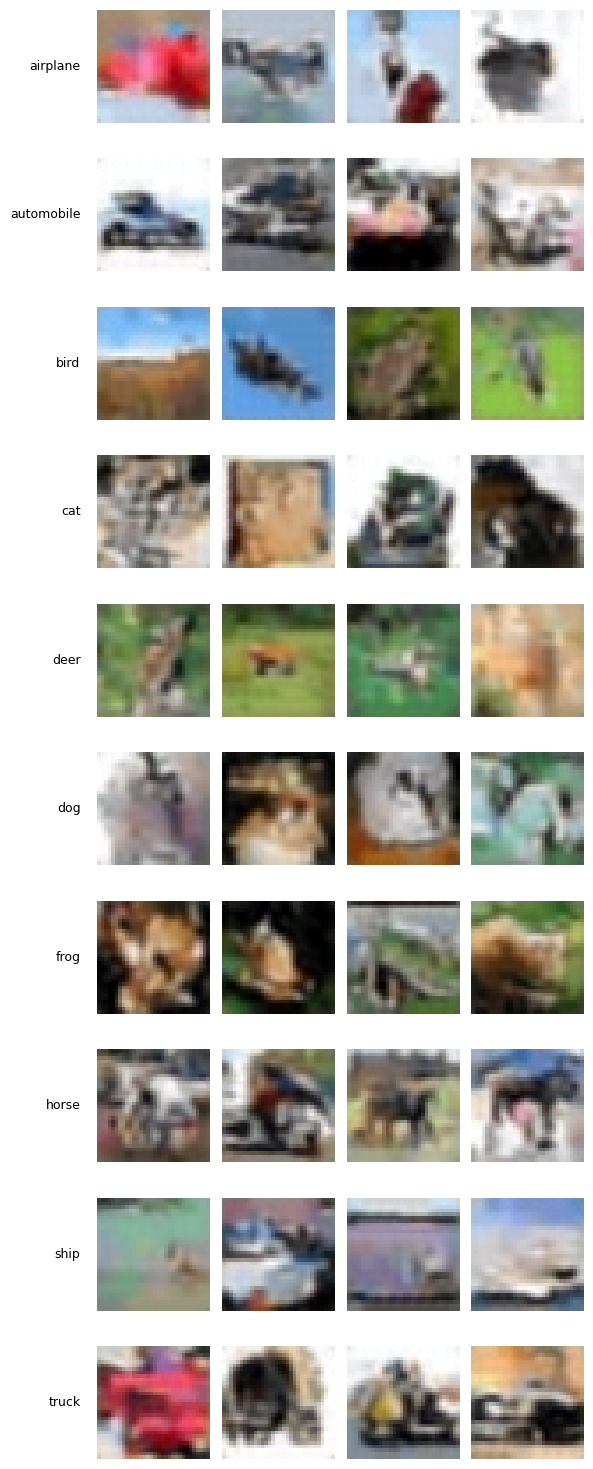

In [5]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

n_samples = 4
all_images = []
for cls in range(10):
    labels = torch.full((n_samples,), cls, dtype=torch.long, device=device)
    imgs = generate(labels)
    all_images.append(imgs.cpu())

fig, axes = plt.subplots(10, n_samples, figsize=(n_samples * 1.5, 15))
for row in range(10):
    for col in range(n_samples):
        ax = axes[row, col]
        ax.imshow(all_images[row][col].permute(1, 2, 0).clamp(0, 1))
        ax.axis('off')
        if col == 0:
            ax.text(-0.15, 0.5, CLASSES[row], transform=ax.transAxes,
                    fontsize=9, va='center', ha='right')
plt.tight_layout()
plt.show()